In [10]:
!pip install pandas numpy matplotlib seaborn

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/31/b4/0eafac990a431561187694126de01f9b12559549b4d86360c0c4bd870fde/pandas-3.0.5-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.1 MB/s eta 0:00:00
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/ad/40/40a40ee0ddf7ceb782c49af278894b686e586d65d8c1889c8b5da01a3d7d/numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/35/74/82bbdf683a301f4478384c8aaba6903631a2ca18294b2d7655c9a542bffb/matplotlib-3.11.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.6 MB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.

In [11]:
import pandas as pd

data = '/Users/youju/Downloads/user_data_mart.csv' 
df = pd.read_csv(data)

print(df.head())
print(df.info())

   user_id  success_payment_count  fail_payment_count  total_points_earned  \
0   838023                      0                   0                 1665   
1   838466                      0                   0                 4748   
2   838642                      0                   0                  344   
3   839357                      0                   0                 3048   
4   839670                      0                   0                  139   

   total_points_spent  point_spend_count user_segment  
0                 600                  2   Non-Paying  
1                3800                 13   Non-Paying  
2                 300                  1   Non-Paying  
3                1700                  6   Non-Paying  
4                   0                  0   Non-Paying  
<class 'pandas.DataFrame'>
RangeIndex: 5037 entries, 0 to 5036
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 포인트 소진율 = 쓴 포인트 / 얻은 포인트 (0으로 나누는 에러 방지)
df['point_utilization_rate'] = np.where(df['total_points_earned'] > 0, 
                                        df['total_points_spent'] / df['total_points_earned'], 0)

# 기초 통계량, 전환율 
total_users = len(df)
paying_users = len(df[df['user_segment'] == 'Paying'])
conversion_rate = paying_users / total_users * 100

print(f"총 유저 수: {total_users}명")
print(f"결제 유저 수: {paying_users}명 (결제 전환율: {conversion_rate:.2f}%)")
print("-" * 50)

# 그룹별 평균치 비교 통계
stats = df.groupby('user_segment')[['total_points_earned', 'total_points_spent', 'point_spend_count']].mean()
print("[그룹별 평균 활동량]")
print(stats)
print("-" * 50)

# 그룹별 평균 포인트 소진율
util_stats = df.groupby('user_segment')['point_utilization_rate'].mean()
print("[그룹별 평균 포인트 소진율]")
print(util_stats)

총 유저 수: 5037명
결제 유저 수: 410명 (결제 전환율: 8.14%)
--------------------------------------------------
[그룹별 평균 활동량]
              total_points_earned  total_points_spent  point_spend_count
user_segment                                                            
Non-Paying            4429.582667         3871.860817          19.934515
Paying                6462.246341         7844.121951          39.868293
--------------------------------------------------
[그룹별 평균 포인트 소진율]
user_segment
Non-Paying    0.864209
Paying        1.325106
Name: point_utilization_rate, dtype: float64


/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/3859697310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_segment', y='point_utilization_rate', data=df, ax=axes[0, 1], palette='Set2')
/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/3859697310.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_segment', y='total_points_earned', data=df, ax=axes[1, 0], palette='Set2', showfliers=False)
/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/3859697310.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the s

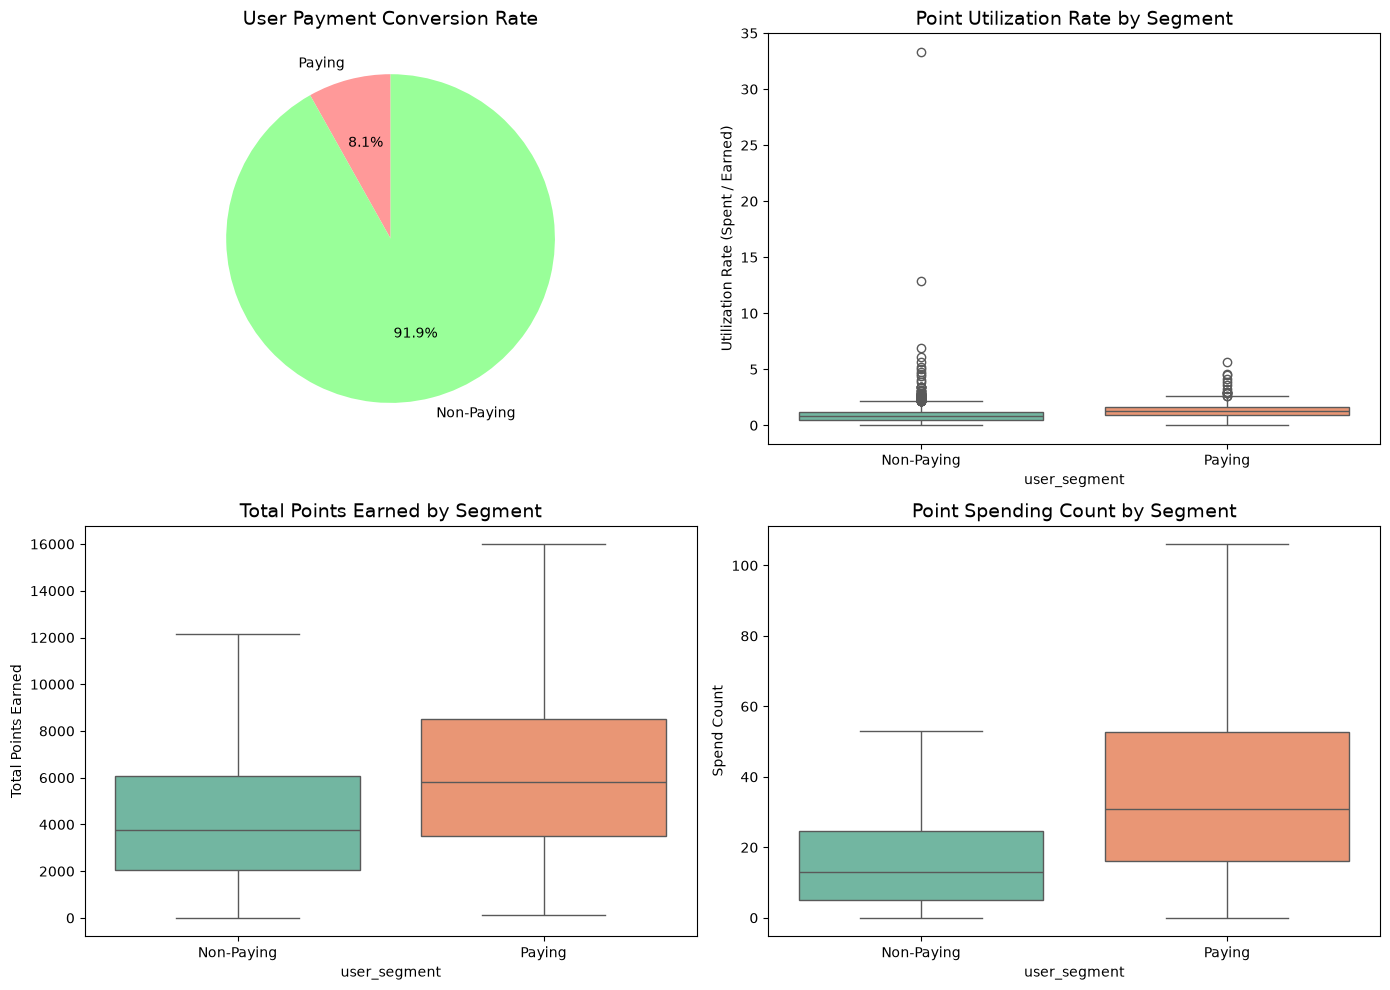

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 결제 유저 비율
labels = ['Paying', 'Non-Paying']
sizes = [paying_users, total_users - paying_users]
colors = ['#ff9999', '#99ff99']
axes[0, 0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title("User Payment Conversion Rate", fontsize=14)

# 그룹별 포인트 소진율 비교
sns.boxplot(x='user_segment', y='point_utilization_rate', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title("Point Utilization Rate by Segment", fontsize=14)
axes[0, 1].set_ylabel("Utilization Rate (Spent / Earned)")

# 그룹별 총 획득 포인트 비교
# showfliers=False를 통해 극단치(Outlier)를 숨겨 박스플롯 몸통을 명확히 보여줍니다
sns.boxplot(x='user_segment', y='total_points_earned', data=df, ax=axes[1, 0], palette='Set2', showfliers=False)
axes[1, 0].set_title("Total Points Earned by Segment", fontsize=14)
axes[1, 0].set_ylabel("Total Points Earned")

# 그룹별 포인트 사용 횟수 비교
sns.boxplot(x='user_segment', y='point_spend_count', data=df, ax=axes[1, 1], palette='Set2', showfliers=False)
axes[1, 1].set_title("Point Spending Count by Segment", fontsize=14)
axes[1, 1].set_ylabel("Spend Count")

plt.tight_layout()
plt.show()

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [23]:
# 데이터 불러오기 및 정제 (음수 오류값 0으로 보정)
df = pd.read_csv('/Users/youju/Downloads/user_payment_time_data_mart.csv')
df['days_to_first_payment'] = df['days_to_first_payment'].apply(lambda x: max(0, x))

# 결제 타이밍 그룹화 (Binning)
bins = [-1, 0, 3, 7, 14, np.inf]
labels = ['가입 당일 (Day 0)', '1~3 days', '4~7 days', '8~14 days', '14 days over']
df['payment_timing_group'] = pd.cut(df['days_to_first_payment'], bins=bins, labels=labels)
group_counts = df['payment_timing_group'].value_counts().reindex(labels)

/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/4164180759.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, ax=axes[1], palette='viridis')
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfon

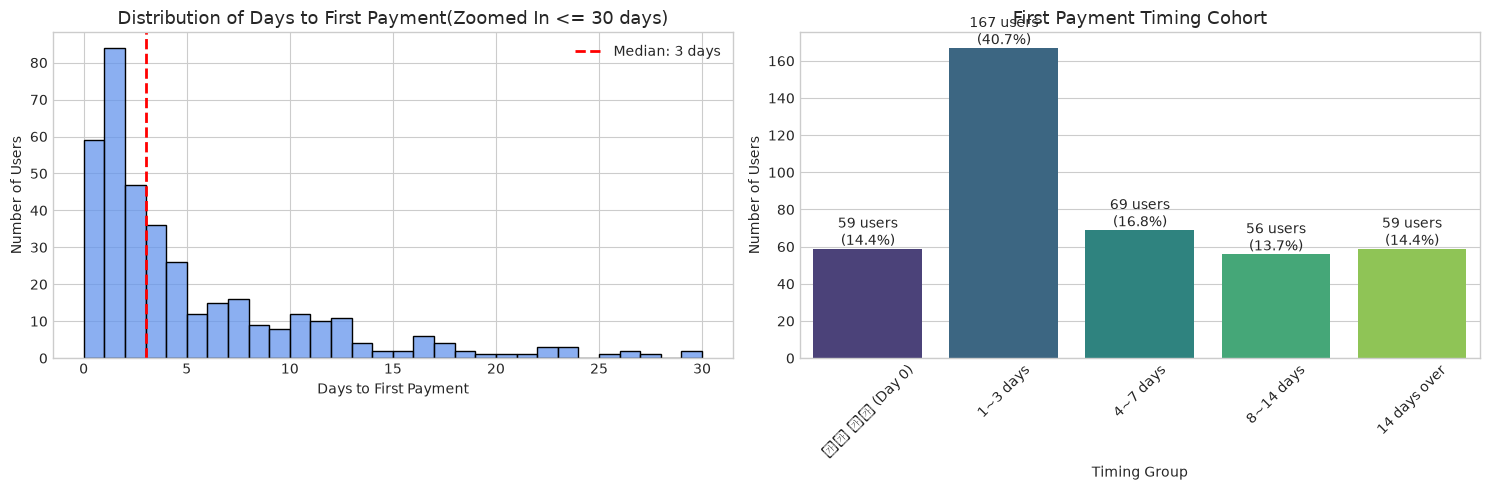

In [24]:
# 시각화 캔버스 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 결제 소요일 히스토그램 (30일 이내로 줌인)
sns.histplot(df[df['days_to_first_payment'] <= 30]['days_to_first_payment'], bins=30, kde=False, ax=axes[0], color='cornflowerblue')
axes[0].set_title("Distribution of Days to First Payment(Zoomed In <= 30 days)", fontsize=13)
axes[0].set_xlabel("Days to First Payment")
axes[0].set_ylabel("Number of Users")

# 중앙값 점선 표시
median_val = df['days_to_first_payment'].median()
axes[0].axvline(median_val, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.0f} days')
axes[0].legend()

# 결제 타이밍 그룹별 비중 바 차트
sns.barplot(x=group_counts.index, y=group_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title("First Payment Timing Cohort", fontsize=13)
axes[1].set_xlabel("Timing Group")
axes[1].set_ylabel("Number of Users")
axes[1].tick_params(axis='x', rotation=45)

# 바 위에 수치 및 퍼센트 표시
for i, v in enumerate(group_counts.values):
    axes[1].text(i, v + 2, f"{v} users\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
# 데이터 불러오기
df = pd.read_csv('/Users/youju/Downloads/app_usage_time.csv')

# 그룹별 기초 통계량 출력
print("=== 앱 생존 기간(Lifespan Days) 기초 통계 ===")
print(df.groupby('user_segment')['lifespan_days'].describe())

=== 앱 생존 기간(Lifespan Days) 기초 통계 ===
               count        mean        std  min   25%   50%    75%    max
user_segment                                                              
Non-Paying    4627.0   86.515021  72.180925  0.0  31.0  70.0  128.0  375.0
Paying         410.0  107.782927  83.280738  7.0  41.0  79.0  138.0  369.0


/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/1296534222.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='user_segment', y='lifespan_days', ax=axes[1], palette=['#99ff99', '#ff9999'])
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not 

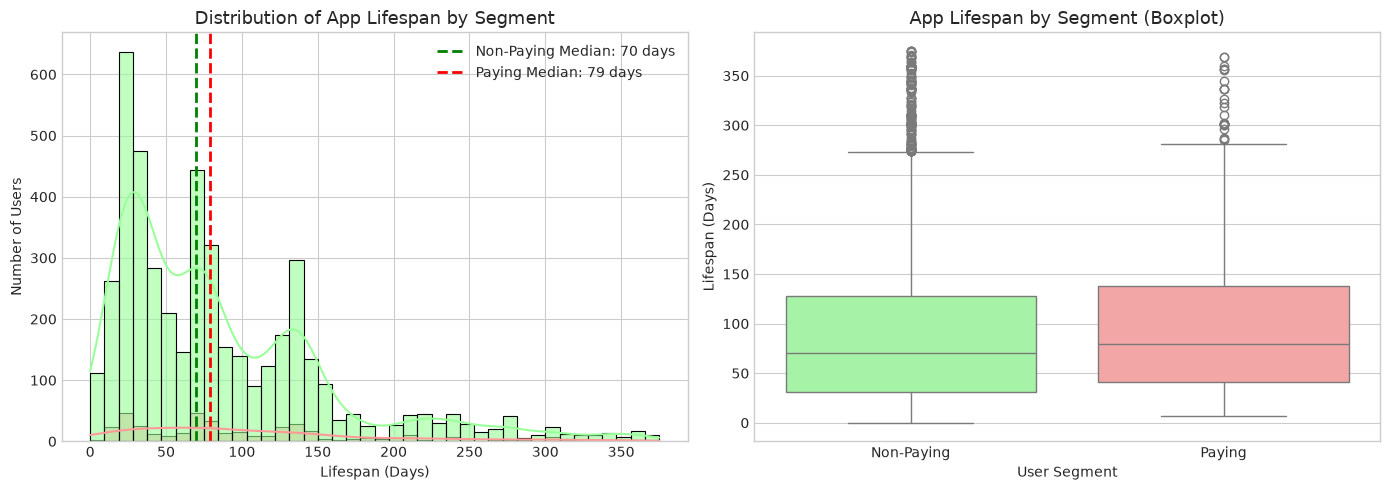

In [27]:
# 시각화 캔버스 설정
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 생존 기간 분포 (히스토그램)
sns.histplot(data=df, x='lifespan_days', hue='user_segment', bins=40, kde=True, ax=axes[0], palette=['#99ff99', '#ff9999'], alpha=0.6)
axes[0].set_title("Distribution of App Lifespan by Segment", fontsize=13)
axes[0].set_xlabel("Lifespan (Days)")
axes[0].set_ylabel("Number of Users")

# 중앙값 라인 추가
median_non_paying = df[df['user_segment'] == 'Non-Paying']['lifespan_days'].median()
median_paying = df[df['user_segment'] == 'Paying']['lifespan_days'].median()
axes[0].axvline(median_non_paying, color='green', linestyle='dashed', linewidth=2, label=f'Non-Paying Median: {median_non_paying:.0f} days')
axes[0].axvline(median_paying, color='red', linestyle='dashed', linewidth=2, label=f'Paying Median: {median_paying:.0f} days')
axes[0].legend()

# 생존 기간 박스플롯
sns.boxplot(data=df, x='user_segment', y='lifespan_days', ax=axes[1], palette=['#99ff99', '#ff9999'])
axes[1].set_title("App Lifespan by Segment (Boxplot)", fontsize=13)
axes[1].set_xlabel("User Segment")
axes[1].set_ylabel("Lifespan (Days)")

plt.tight_layout()
plt.show()

In [29]:
# 데이터 불러오기
df = pd.read_csv('/Users/youju/Downloads/user_data_mart.csv')

total_users = len(df)
paying_users = len(df[df['user_segment'] == 'Paying'])

/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/2228783798.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_segment', y='total_points_earned', data=df, ax=axes[1], palette='Set2', showfliers=False)
/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/2228783798.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_segment', y='point_spend_count', data=df, ax=axes[2], palette='Set2', showfliers=False)
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
f

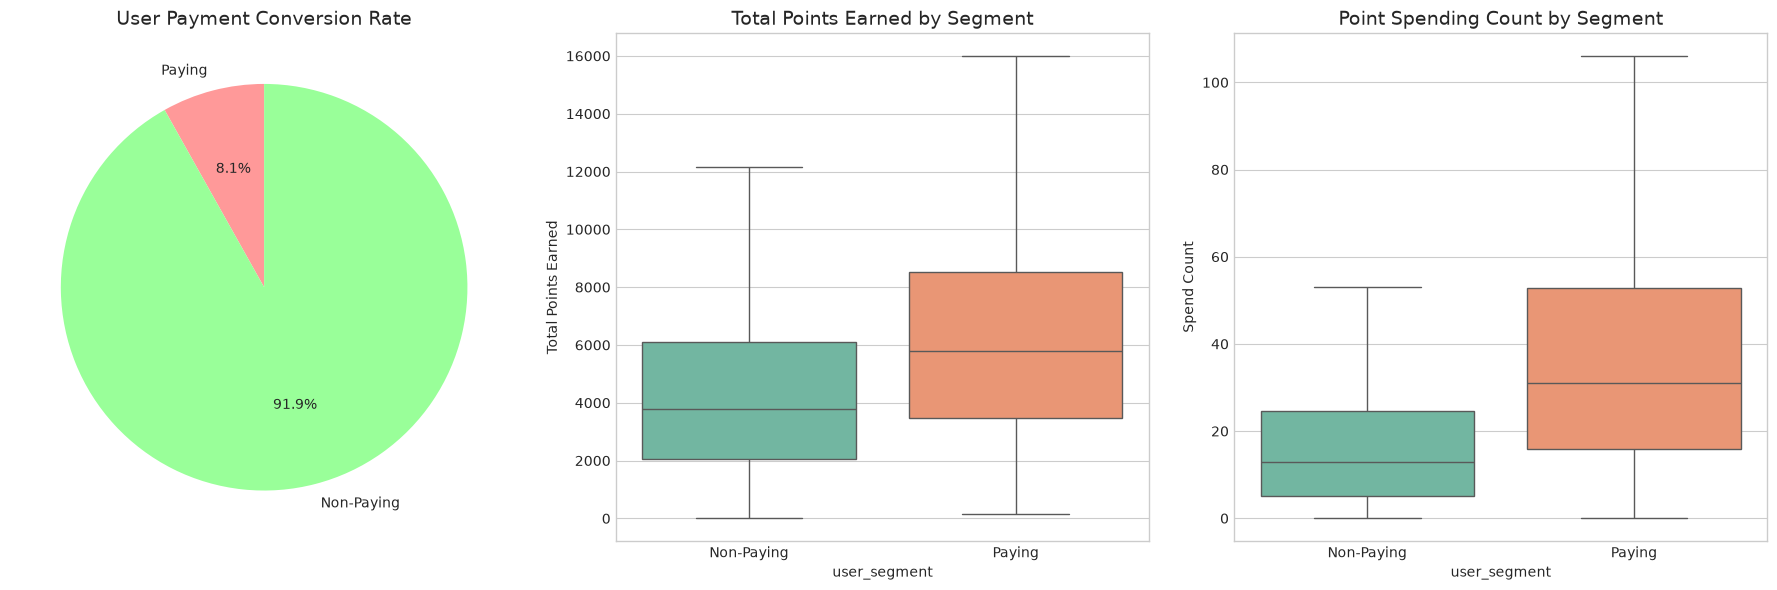

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 결제 유저 비율 (파이 차트)
labels = ['Paying', 'Non-Paying']
sizes = [paying_users, total_users - paying_users]
colors = ['#ff9999', '#99ff99']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title("User Payment Conversion Rate", fontsize=14)

# 그룹별 총 획득 포인트 비교
sns.boxplot(x='user_segment', y='total_points_earned', data=df, ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title("Total Points Earned by Segment", fontsize=14)
axes[1].set_ylabel("Total Points Earned")

# 그룹별 포인트 사용 횟수 비교
sns.boxplot(x='user_segment', y='point_spend_count', data=df, ax=axes[2], palette='Set2', showfliers=False)
axes[2].set_title("Point Spending Count by Segment", fontsize=14)
axes[2].set_ylabel("Spend Count")

plt.tight_layout()
plt.show()

In [32]:
df = pd.read_csv('/Users/youju/Downloads/class_info.csv')

# 지역명 첫 단어 추출 (예: '서울특별시 강남구' -> '서울특별시')
df['primary_region'] = df['region'].apply(lambda x: str(x).split()[0])

# 한글 -> 영문 다이렉트 맵핑 딕셔너리
eng_map = {
    '서울특별시': 'Seoul', '서울': 'Seoul',
    '경기도': 'Gyeonggi', '경기': 'Gyeonggi',
    '인천광역시': 'Incheon', '인천': 'Incheon',
    '강원도': 'Gangwon', '강원': 'Gangwon',
    '충청남도': 'Chungnam', '충남': 'Chungnam',
    '충청북도': 'Chungbuk', '충북': 'Chungbuk',
    '대전광역시': 'Daejeon', '대전': 'Daejeon',
    '세종특별자치시': 'Sejong', '세종': 'Sejong',
    '전라북도': 'Jeonbuk', '전북': 'Jeonbuk',
    '전라남도': 'Jeonnam', '전남': 'Jeonnam',
    '광주광역시': 'Gwangju', '광주': 'Gwangju',
    '경상북도': 'Gyeongbuk', '경북': 'Gyeongbuk',
    '경상남도': 'Gyeongnam', '경남': 'Gyeongnam',
    '대구광역시': 'Daegu', '대구': 'Daegu',
    '울산광역시': 'Ulsan', '울산': 'Ulsan',
    '부산광역시': 'Busan', '부산': 'Busan',
    '제주특별자치도': 'Jeju', '제주': 'Jeju'
}

# 맵핑 적용 및 집계 (맵핑 안 되는 값은 'Other'로 처리)
df['Region_EN'] = df['primary_region'].map(eng_map).fillna('Other')
region_counts = df['Region_EN'].value_counts().reset_index()
region_counts.columns = ['Region', 'User Count']

/var/folders/t0/85xt099562dflgf6nvxdqgl00000gn/T/ipykernel_38849/4000799811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_counts, x='Region', y='User Count', palette='viridis')


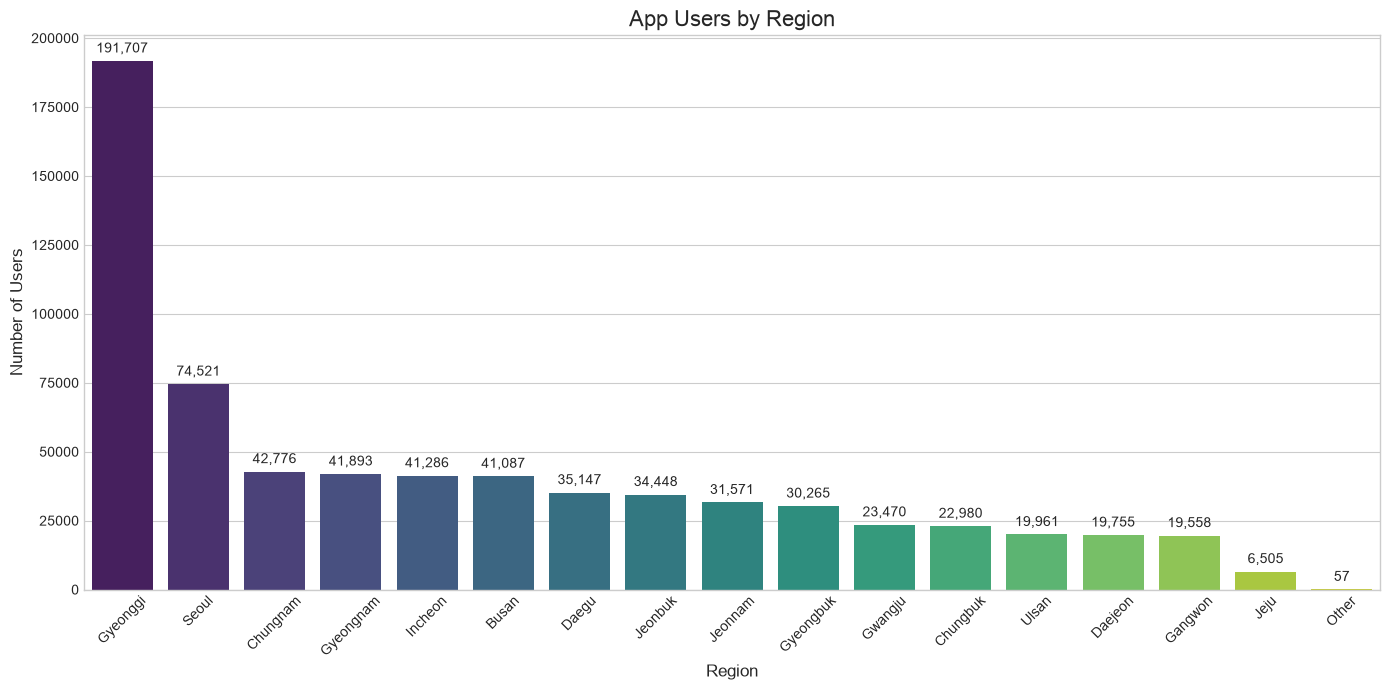

In [33]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))
sns.barplot(data=region_counts, x='Region', y='User Count', palette='viridis')

plt.title('App Users by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(region_counts['User Count']):
    plt.text(i, v + 2000, f"{v:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기 및 경기도 필터링
df = pd.read_csv('class_info.csv')
df['primary_region'] = df['region'].apply(lambda x: str(x).split()[0])
gyeonggi_df = df[df['primary_region'].isin(['경기도', '경기'])]

# 2. 학교 종류별 카운트 (H=고등학교, M=중학교)
labels = ['High School (H)', 'Middle School (M)']
counts = [103427, 88280] # 파이썬 집계 결과값

# 3. 시각화 캔버스 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [1] 비율을 보여주는 파이 차트
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
axes[0].set_title('Gyeonggi Region: Users by School Type (%)', fontsize=14)

# [2] 정확한 인원수를 보여주는 바 차트
sns.barplot(x=labels, y=counts, ax=axes[1], palette=['#ff9999', '#66b3ff'])
axes[1].set_title('Number of Users by School Type (Gyeonggi)', fontsize=14)
axes[1].set_ylabel('Number of Users')
for i, v in enumerate(counts):
    axes[1].text(i, v + 1500, f"{v:,}", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

# 1. 데이터 불러오기
df_user = pd.read_csv('/Users/youju/Downloads/class_user.csv')
df_info = pd.read_csv('/Users/youju/Downloads/class_info.csv')
    
# 2. user_id를 기준으로 테이블 병합 (JOIN)
df_merged = pd.merge(df_user[['user_id', 'school_id']], 
                     df_info[['user_id', 'region', 'school_type']], 
                     on='user_id', how='inner')

# 3. 지역명 정제 (첫 단어만 추출)
df_merged['primary_region'] = df_merged['region'].apply(lambda x: str(x).split()[0])

# 4. 학교 ID별로 그룹화하여 유저 수 카운트
school_counts = df_merged.groupby(['school_id', 'primary_region', 'school_type']).agg(
    user_count=('user_id', 'count')
).reset_index()

# 5. 유저 수가 많은 순서대로 내림차순 정렬하여 Top 10 출력
top_schools = school_counts.sort_values(by='user_count', ascending=False).head(10)
print(top_schools)

      school_id primary_region school_type  user_count
331         369           충청남도           H         578
1572       1719          울산광역시           H         551
4193       4516            경기도           H         510
5021       5372            경기도           H         507
5164       5520            경기도           M         500
242         271           충청남도           H         492
316         352           충청남도           H         491
1346       1478          인천광역시           M         488
4108       4426           경상남도           H         487
5137       5491            경기도           H         486


In [35]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv('/Users/youju/Downloads/action_count_school.csv')

# 2. 학교 규모별 구간(Binning) 설정
bins = [0, 50, 100, 200, 300, 400, 500, 1000]
labels = ['1~50명', '51~100명', '101~200명', '201~300명', '301~400명', '401~500명', '501명 이상']
df['size_bin'] = pd.root = pd.cut(df['total_school_users'], bins=bins, labels=labels)

# 3. 구간별 학교 수 및 1인당 평균 사용량 집계
summary_table = df.groupby('size_bin', observed=False).agg(
    total_schools=('school_count', 'sum'),
    avg_usage_per_user=('avg_usage_per_user', 'mean')
).reset_index()

# 소수점 둘째 자리 반올림
summary_table['avg_usage_per_user'] = summary_table['avg_usage_per_user'].round(2)

print(summary_table.to_string(index=False))

size_bin  total_schools  avg_usage_per_user
   1~50명          27914                0.00
 51~100명          65045                0.00
101~200명         248025                0.00
201~300명         223373                0.00
301~400명          90772                0.00
401~500명          19712               39.38
 501명 이상           2146              233.73
